In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
u=xr.open_dataset('data/era5_ua_2.5x2.5.nc')
u

<xarray.Dataset> Size: 33MB
Dimensions:         (valid_time: 1021, lon: 144, lat: 28, pressure_level: 2)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-01-01
  * lon             (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * lat             (lat) float64 224B -86.79 -80.36 -73.93 ... 80.36 86.79
  * pressure_level  (pressure_level) float64 16B 850.0 50.0
Data variables:
    u               (valid_time, pressure_level, lat, lon) float32 33MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.0 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Fri Feb 14 12:09:57 2025: cdo remapbil,r144x28 e...
    CDO:                     Climate Data Operators version 2.5.0 (https://mp...

In [9]:
## select u50
u50=u.sel(pressure_level=50).rename({'valid_time':'time'}).drop('pressure_level')
# select time period and latitude
u50=u50.sel(time=slice('1950','2025'))

/tmp/ipykernel_593211/1548602930.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  u50=u.sel(pressure_level=50).rename({'valid_time':'time'}).drop('pressure_level')


In [36]:
#zonal mean
u_zonal = u50.mean(dim="lon")
#interpolate values to -60°S
u_60S = u_zonal.interp(lat=-60)
#rolling window
u_60_roll=u_60S.rolling(time=5, center=True).mean()

#find breakdown date
def find_breakdown_date(u_series):
    """
    u_series: 1D DataArray (time for one year)
    returns: datetime or NaT
    """
    condition = u_series < 10  # threshold

    if condition.any():
        return u_series.time.where(condition, drop=True)[-1].values
    else:
        return np.datetime64("NaT")

##do this for each year
years = np.unique(u_60_roll["time.year"])

breakdown_dates = []

for year in years:
    u_year = u_60_roll.sel(time=str(year))['u']

    date = find_breakdown_date(u_year)
    breakdown_dates.append(date)

breakdown_dates = xr.DataArray(
    breakdown_dates,
    coords={"vortex_year": years},
    dims=["vortex_year"],
    name="vortex_breakdown_date"
)

In [ ]:
breakdown_dates

##convert these into day of the year or days since date_x

<xarray.DataArray 'vortex_breakdown_date' (vortex_year: 76)> Size: 608B
array([                          'NaT', '1951-12-01T00:00:00.000000000',
       '1952-02-01T00:00:00.000000000',                           'NaT',
       '1954-02-01T00:00:00.000000000', '1955-02-01T00:00:00.000000000',
       '1956-02-01T00:00:00.000000000', '1957-12-01T00:00:00.000000000',
       '1958-02-01T00:00:00.000000000', '1959-02-01T00:00:00.000000000',
       '1960-02-01T00:00:00.000000000', '1961-02-01T00:00:00.000000000',
       '1962-02-01T00:00:00.000000000', '1963-02-01T00:00:00.000000000',
       '1964-12-01T00:00:00.000000000', '1965-02-01T00:00:00.000000000',
       '1966-02-01T00:00:00.000000000', '1967-12-01T00:00:00.000000000',
       '1968-12-01T00:00:00.000000000', '1969-02-01T00:00:00.000000000',
       '1970-02-01T00:00:00.000000000', '1971-02-01T00:00:00.000000000',
       '1972-02-01T00:00:00.000000000', '1973-02-01T00:00:00.000000000',
       '1974-02-01T00:00:00.000000000', '1975-02-01T00:00:00.000000000',
       '1976-02-01T00:00:00.000000000', '1977-02-01T00:00:00.000000000',
       '1978-02-01T00:00:00.000000000', '1979-02-01T00:00:00.000000000',
       '1980-02-01T00:00:00.000000000', '1981-02-01T00:00:00.000000000',
                                 'NaT', '1983-02-01T00:00:00.000000000',
       '1984-02-01T00:00:00.000000000', '1985-02-01T00:00:00.000000000',
       '1986-02-01T00:00:00.000000000', '1987-02-01T00:00:00.000000000',
       '1988-02-01T00:00:00.000000000', '1989-02-01T00:00:00.000000000',
       '1990-02-01T00:00:00.000000000', '1991-02-01T00:00:00.000000000',
       '1992-02-01T00:00:00.000000000', '1993-02-01T00:00:00.000000000',
       '1994-02-01T00:00:00.000000000', '1995-02-01T00:00:00.000000000',
                                 'NaT', '1997-02-01T00:00:00.000000000',
       '1998-02-01T00:00:00.000000000',                           'NaT',
                                 'NaT', '2001-02-01T00:00:00.000000000',
       '2002-12-01T00:00:00.000000000', '2003-02-01T00:00:00.000000000',
       '2004-02-01T00:00:00.000000000', '2005-02-01T00:00:00.000000000',
       '2006-02-01T00:00:00.000000000', '2007-02-01T00:00:00.000000000',
                                 'NaT',                           'NaT',
       '2010-02-01T00:00:00.000000000',                           'NaT',
       '2012-12-01T00:00:00.000000000', '2013-02-01T00:00:00.000000000',
       '2014-02-01T00:00:00.000000000',                           'NaT',
                                 'NaT', '2017-02-01T00:00:00.000000000',
       '2018-02-01T00:00:00.000000000', '2019-12-01T00:00:00.000000000',
       '2020-02-01T00:00:00.000000000',                           'NaT',
                                 'NaT',                           'NaT',
                                 'NaT',                           'NaT'],
      dtype='datetime64[ns]')
Coordinates:
  * vortex_year  (vortex_year) int64 608B 1950 1951 1952 1953 ... 2023 2024 2025

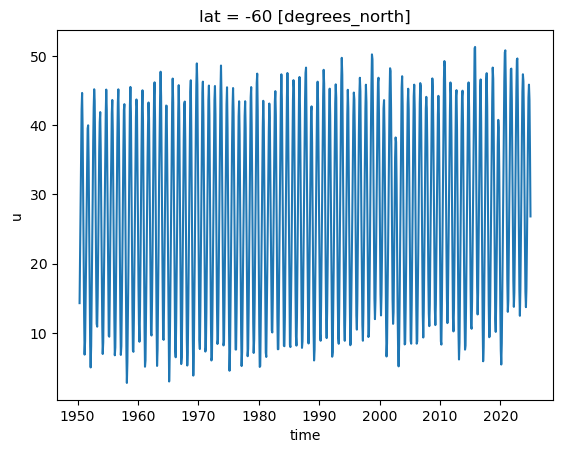